In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# student Exam Score Prediction (Regression Problem)

In [3]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [4]:
train_df.shape

(630000, 13)

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [6]:
train_df.isna().sum()

id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [7]:
train_df.duplicated().sum()

np.int64(0)

In [8]:
# we dont have duplicates and we dont have Null / Missing values

In [9]:
numerical_cate = train_df.select_dtypes(include=['float64', 'int']).columns
categorical_cate = train_df.select_dtypes(include=['object']).columns

In [10]:
print(numerical_cate)
print(categorical_cate)

Index(['id', 'age', 'study_hours', 'class_attendance', 'sleep_hours',
       'exam_score'],
      dtype='object')
Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')


<Axes: >

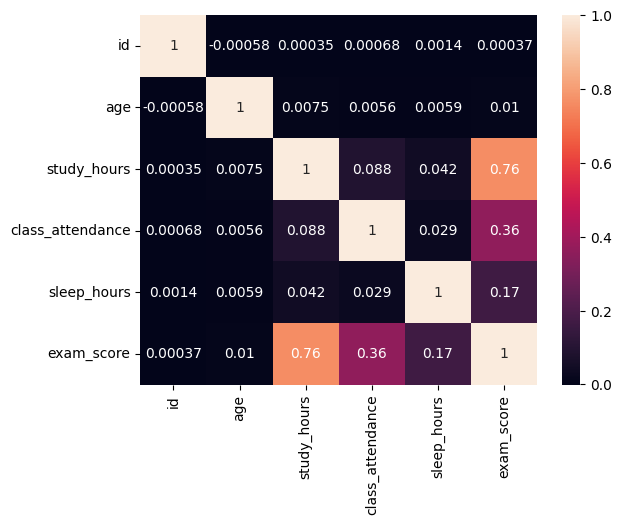

In [11]:
sns.heatmap(train_df[numerical_cate].corr(), annot=True)

In [12]:
# we can see that id should be removed (we dont need it for analysis), but after looking at the heat map, cols like age can be removed and sleep hours has positive correlation but its very less

In [13]:
X_num = train_df[numerical_cate]
y = train_df['exam_score']


corr_with_target = X_num.corrwith(y)

threshold = 0.05

selected_features = corr_with_target[
    corr_with_target.abs() <= threshold
].index.tolist()

print(selected_features)
train_df.drop(columns=selected_features, inplace=True)

['id', 'age']


In [14]:
# so we can use elastic net for this problem and we can also use ridge and lasso models as well.


In [15]:
numerical_cate = train_df.select_dtypes(include=['float64', 'int']).columns
categorical_cate = train_df.select_dtypes(include=['object']).columns

In [16]:
print(numerical_cate)
print(categorical_cate)

Index(['study_hours', 'class_attendance', 'sleep_hours', 'exam_score'], dtype='object')
Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')


In [17]:
def remove_outliers_iqr(df, cols):
    df_clean = df.copy()

    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_clean = df_clean[
            (df_clean[col] >= lower) & (df_clean[col] <= upper)
        ]

    return df_clean


In [18]:
train_df = remove_outliers_iqr(train_df, numerical_cate)

In [19]:
sleep_quality_order = ['poor', 'average', 'good']
facility_rating_order = ['low', 'medium', 'high']
exam_difficulty_order = ['easy', 'moderate', 'hard']
# ordinal encoding for above

In [20]:
# Step 1: create interaction on raw data
train_df['sleep_efficiency'] = (
    train_df['sleep_hours'] *
    train_df['sleep_quality'].map({'poor': 1, 'average': 2, 'good': 3})
)

# t1['sleep_efficiency'] = (
#     t1['sleep_hours'] *
#     t1['sleep_quality'].map({'poor': 1, 'average': 2, 'good': 3})
# )




In [21]:
train_df.head(10)

,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,sleep_efficiency
0,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3,9.8
1,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7,4.7
2,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0,5.8
3,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9,16.6
4,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0,28.8
5,male,b.com,5.04,85.1,yes,9.4,average,online videos,medium,moderate,70.1,18.8
6,male,b.sc,4.28,87.0,no,9.1,average,mixed,high,moderate,63.4,18.2
7,female,ba,4.19,44.9,yes,8.8,good,self-study,high,hard,76.8,26.4
8,other,b.com,1.06,98.3,yes,5.0,poor,mixed,low,moderate,46.7,5.0
9,male,bba,3.44,80.9,yes,6.2,good,group study,medium,easy,58.2,18.6


In [22]:
ordinal_cols = [
   
    'facility_rating',
    'exam_difficulty'
]

ordinal_categories = [
           # sleep_quality
    ['low', 'medium', 'high'],             # facility_rating
    ['easy', 'moderate', 'hard']            # exam_difficulty
]


In [23]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder(
    categories=ordinal_categories,
    handle_unknown='use_encoded_value',
    unknown_value=-1
)


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_cols = train_df.select_dtypes(include=['float64', 'int']).columns.to_list()
# numerical_cols.remove('exam_score')
numerical_cols.remove('exam_score')

nominal_cols = [
    'gender', 'course', 'study_method', 'internet_access'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('ord', ordinal_encoder, ordinal_cols),
        ('nom', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_cols)
    ]
)

X_transformed = preprocessor.fit_transform(train_df)
feature_names = preprocessor.get_feature_names_out()
X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)

X_transformed_df.head()
X_transformed_df.columns = (
    X_transformed_df.columns.str.replace(r'^(num|ord|nom)__', '', regex=True)
)

train_df = X_transformed_df

numerical_cols


['study_hours', 'class_attendance', 'sleep_hours', 'sleep_efficiency']

In [25]:
# feature engineering lets add 
# effective_study = study_hours × class_attendance
# sleep_efficiency = sleep_hours × sleep_quality_score

train_df['effective_study'] = train_df['study_hours'] * train_df['class_attendance']
# t1['effective_study'] = t1['study_hours'] * t1['class_attendance']




In [26]:
# train_df.drop(columns=['study_hours', 'class_attendance', 'sleep_hours'], inplace=True)

In [27]:
train_df.head()

,study_hours,class_attendance,sleep_hours,sleep_efficiency,facility_rating,exam_difficulty,gender_male,gender_other,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,internet_access_yes,effective_study
0,1.655875,1.538302,-1.245269,-0.624446,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.547236
1,0.401573,1.308814,-1.359895,-1.352275,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.525584
2,0.287160,1.182595,-0.729454,-1.195292,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.339594
3,-0.848492,-1.290141,0.703367,0.345993,2.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.094674
4,1.545699,0.855575,1.448434,2.087074,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.322461


<Axes: >

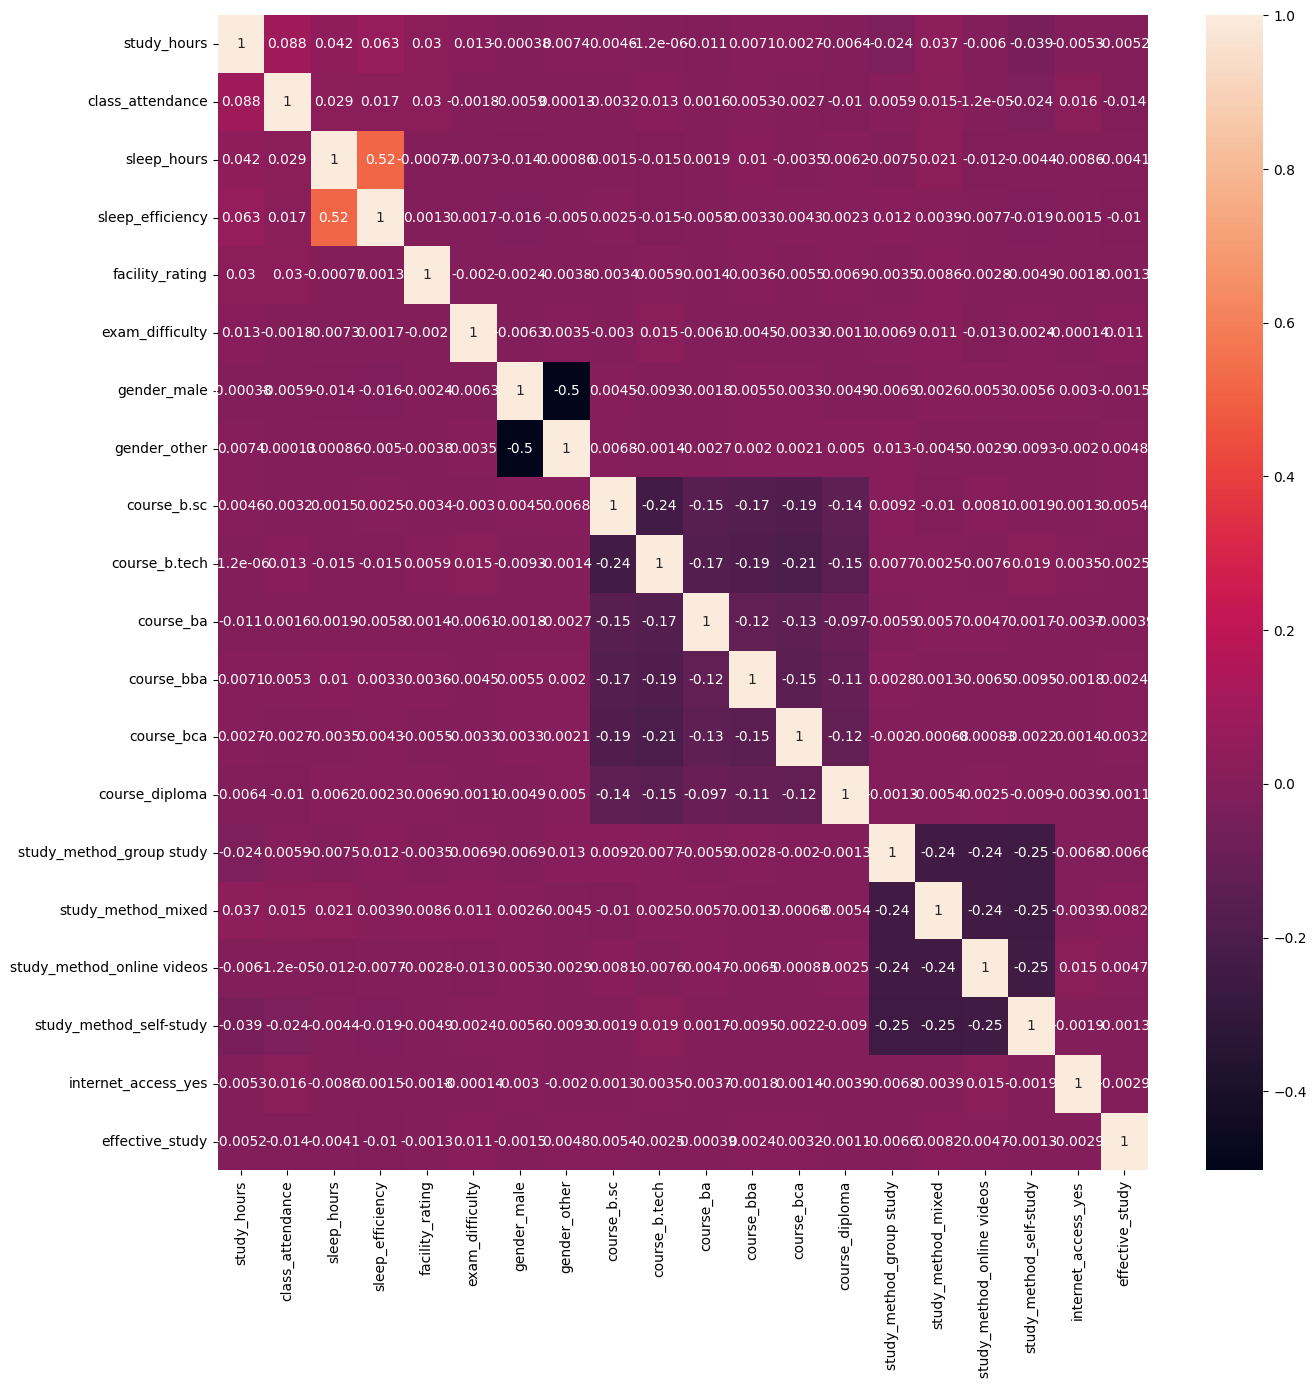

In [28]:
plt.figure(figsize=(15,15))
sns.heatmap(train_df.corr(), annot=True)

In [29]:
# ill try to remove cols which have less 0.05 correlation with examscores and these removed columns can also be removed from test data

In [30]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV  
from sklearn.model_selection import train_test_split

# from sklearn.preprocessing import StandardScaler

In [31]:
train_df

,study_hours,class_attendance,sleep_hours,sleep_efficiency,facility_rating,exam_difficulty,gender_male,gender_other,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,internet_access_yes,effective_study
0,1.655875,1.538302,-1.245269,-0.624446,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.547236
1,0.401573,1.308814,-1.359895,-1.352275,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.525584
2,0.287160,1.182595,-0.729454,-1.195292,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.339594
3,-0.848492,-1.290141,0.703367,0.345993,2.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.094674
4,1.545699,0.855575,1.448434,2.087074,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.322461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,0.363435,-0.073853,-1.703772,-0.267667,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.026841
629996,1.304162,-1.009018,-1.474521,-0.738615,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-1.315922
629997,-1.424793,-1.594213,-1.589146,-1.409360,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,2.271423
629998,-1.043417,0.178584,0.646054,0.317451,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.186338


In [32]:
df = pd.read_csv('train.csv')

In [33]:
# dependent and independent vars
# X = train_df.drop(columns=['exam_score'])
X= train_df
y = pd.DataFrame(df['exam_score'])

In [34]:
# ridgeCV = RidgeCV()
# lassocv = LassoCV()
# elastic = ElasticNetCV()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [35]:
X_test

,study_hours,class_attendance,sleep_hours,sleep_efficiency,facility_rating,exam_difficulty,gender_male,gender_other,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,internet_access_yes,effective_study
364426,-0.395079,0.935896,-1.703772,-0.852784,0.0,2.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.369752
224752,-0.306091,-1.284404,-0.041700,-1.024038,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.393144
110423,0.189697,-1.691745,-0.213638,0.845484,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.320920
272555,0.079522,0.620349,-0.786767,-1.209563,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.049331
199651,-1.140880,1.102275,0.817993,-0.809971,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-1.257563
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375447,-1.611243,-1.324564,-1.589146,-1.409360,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.134194
337425,0.969398,0.872786,1.104557,0.545789,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.846078
273244,-0.195916,0.270380,0.531429,0.260366,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.052972
396263,-0.992567,-0.016481,1.563060,2.172701,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.016358


In [36]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
alpha=[0.1, 1, 10, 0.5, 0.01]

from sklearn.model_selection import KFold

kfold = KFold(n_splits=5, shuffle=True, random_state=42)


In [38]:
ridgeCV = RidgeCV(cv=kfold)
lassocv = LassoCV(cv=kfold)
elastic = ElasticNetCV(cv=kfold, n_jobs=-1)

In [39]:
ridgeCV.fit(X_train_scaled, y_train)
lassocv.fit(X_train_scaled, y_train)
elastic.fit(X_train_scaled, y_train)


d:\work\Data_Science_Practice\Practice\pract_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\work\Data_Science_Practice\Practice\pract_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"l1_ratio l1_ratio: float or list of float, default=0.5Float between 0 and 1 passed to ElasticNet (scaling betweenl1 and l2 penalties). For ``l1_ratio = 0``the penalty is an L2 penalty. For ``l1_ratio = 1`` it is an L1 penalty.For ``0 < l1_ratio < 1``, the penalty is a combination of L1 and L2This parameter can be a list, in which case the differentvalues are tested by cross-validation and the one giving the bestprediction score is used. Note that a good choice of list ofvalues for l1_ratio is often to put more values close to 1(i.e. Lasso) and less close to 0 (i.e. Ridge), as in ``[.1, .5, .7,.9, .95, .99, 1]``.",0.5
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path, used for each l1_ratio... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path, used for each l1_ratio.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"verbose verbose: bool or int, default=0Amount of verbosity.",0


In [40]:
y_pred1 = ridgeCV.predict(X_test_scaled)
y_pred2 = lassocv.predict(X_test_scaled)
y_pred3 = elastic.predict(X_test_scaled)

In [41]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [42]:
n = X_test.shape[0]   # number of samples
p = X_test.shape[1]   # number of features

In [43]:
# for ridge
r2 = r2_score(y_test, y_pred1)
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print('For RidgeCV')
print('r2_score : ', r2)
print('adjusted r2_score : ', adjusted_r2)
print('mae : ', mean_absolute_error(y_test, y_pred1))
print('mse : ', mean_squared_error(y_test, y_pred1))



For RidgeCV
r2_score :  0.7764830826192692
adjusted r2_score :  0.7764594274070625
mae :  7.12651351161446
mse :  79.62963007169307


In [44]:
# for lasso
r2 = r2_score(y_test, y_pred2)
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print('For LassoCV')
print('r2_score : ', r2)
print('adjusted r2_score : ', adjusted_r2)

print('mae : ', mean_absolute_error(y_test, y_pred2))
print('mse : ', mean_squared_error(y_test, y_pred2))


For LassoCV
r2_score :  0.7764760873422976
adjusted r2_score :  0.7764524313897676
mae :  7.127440556522358
mse :  79.63212219320242


In [45]:
# for Elastic
r2 =  r2_score(y_test, y_pred3)
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print('For ElasticNet CV')
print('r2_score : ',r2)
print('adjusted r2_score : ', adjusted_r2)
print('mae : ', mean_absolute_error(y_test, y_pred3))
print('mse : ', mean_squared_error(y_test, y_pred3))


For ElasticNet CV
r2_score :  0.7762371726490874
adjusted r2_score :  0.77621349141177
mae :  7.13517770629499
mse :  79.71723739997046


In [46]:
pd.DataFrame(X_train_scaled)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,-0.961525,-0.027998,-1.302932,-0.653357,0.017678,0.188181,-0.708854,-0.710157,-0.464164,-0.512527,-0.331057,-0.369191,-0.405049,-0.29294,-0.492726,2.033223,-0.487766,-0.513278,0.295188,-0.062507
1,-0.643611,-1.478779,0.474601,1.358866,-1.212749,0.188181,-0.708854,1.408138,2.154409,-0.512527,-0.331057,-0.369191,-0.405049,-0.29294,2.029527,-0.491830,-0.487766,-0.513278,0.295188,0.871948
2,-1.126840,-1.031503,-1.130913,-1.295555,0.017678,0.188181,-0.708854,-0.710157,-0.464164,-0.512527,-0.331057,-0.369191,-0.405049,3.41367,-0.492726,-0.491830,-0.487766,-0.513278,0.295188,1.083365
3,-0.719910,-0.458071,0.761299,1.572933,0.017678,0.188181,1.410728,-0.710157,-0.464164,1.951116,-0.331057,-0.369191,-0.405049,-0.29294,-0.492726,-0.491830,-0.487766,1.948261,0.295188,0.243423
4,-0.427430,1.428518,-0.500175,-0.253766,-1.212749,1.725025,1.410728,-0.710157,-0.464164,1.951116,-0.331057,-0.369191,-0.405049,-0.29294,-0.492726,-0.491830,-0.487766,1.948261,0.295188,-0.707380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440995,-0.474057,1.227817,-0.557515,-1.152845,-1.212749,0.188181,1.410728,-0.710157,-0.464164,-0.512527,-0.331057,2.708624,-0.405049,-0.29294,-0.492726,-0.491830,-0.487766,1.948261,0.295188,-0.678286
440996,1.229961,0.144032,-1.589631,-0.796067,0.017678,0.188181,1.410728,-0.710157,-0.464164,-0.512527,-0.331057,-0.369191,2.468839,-0.29294,-0.492726,-0.491830,2.050164,-0.513278,0.295188,0.088718
440997,-1.042063,-0.727584,0.761299,1.572933,-1.212749,1.725025,-0.708854,1.408138,-0.464164,-0.512527,-0.331057,-0.369191,-0.405049,-0.29294,-0.492726,2.033223,-0.487766,-0.513278,0.295188,0.675586
440998,0.975630,0.941102,-0.500175,-1.138573,-1.212749,0.188181,-0.708854,1.408138,-0.464164,1.951116,-0.331057,-0.369191,-0.405049,-0.29294,2.029527,-0.491830,-0.487766,-0.513278,0.295188,0.834080


In [47]:
X_train

,study_hours,class_attendance,sleep_hours,sleep_efficiency,facility_rating,exam_difficulty,gender_male,gender_other,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,internet_access_yes,effective_study
445840,-0.962904,-0.027955,-1.302582,-0.652988,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.026918
468919,-0.645091,-1.479469,0.474116,1.359245,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.954393
237423,-1.128167,-1.031966,-1.130644,-1.295190,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.164231
443580,-0.721367,-0.458246,0.760680,1.573313,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.330563
295133,-0.428979,1.429295,-0.500202,-0.253396,0.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,-0.613137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110268,-0.475591,1.228493,-0.557515,-1.152479,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,-0.584261
259178,1.227886,0.144161,-1.589146,-0.795700,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.177013
365838,-1.043417,-0.727894,0.760680,1.573313,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.759497
131932,0.973636,0.941633,-0.500202,-1.138208,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.916808


In [48]:
test_df = pd.read_csv('test.csv')

In [49]:
test_df.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
1,630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
2,630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate
3,630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate
4,630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate


In [51]:
t1 = test_df.drop(columns=['id'])

In [52]:
t1

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
1,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
2,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate
3,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate
4,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate
...,...,...,...,...,...,...,...,...,...,...,...
269995,21,other,b.com,2.55,82.3,yes,8.4,average,mixed,medium,hard
269996,17,female,b.com,0.49,46.4,yes,8.8,good,mixed,low,easy
269997,22,male,bba,6.62,74.7,yes,5.5,good,coaching,high,easy
269998,22,other,ba,4.08,51.8,yes,8.7,poor,online videos,high,moderate


In [53]:
t1['sleep_efficiency'] = (
    t1['sleep_hours'] *
    t1['sleep_quality'].map({'poor': 1, 'average': 2, 'good': 3})
)

In [54]:
ordinal_cols = [
   
    'facility_rating',
    'exam_difficulty'
]

ordinal_categories = [
           # sleep_quality
    ['low', 'medium', 'high'],             # facility_rating
    ['easy', 'moderate', 'hard']            # exam_difficulty
]


In [55]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder(
    categories=ordinal_categories,
    handle_unknown='use_encoded_value',
    unknown_value=-1
)


In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_cols = t1.select_dtypes(include=['float64', 'int']).columns.to_list()
# numerical_cols.remove('exam_score')
# numerical_cols.remove('exam_score')

nominal_cols = [
    'gender', 'course', 'study_method', 'internet_access'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('ord', ordinal_encoder, ordinal_cols),
        ('nom', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_cols)
    ]
)

X_transformed = preprocessor.fit_transform(t1)
feature_names = preprocessor.get_feature_names_out()
X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)

X_transformed_df.head()
X_transformed_df.columns = (
    X_transformed_df.columns.str.replace(r'^(num|ord|nom)__', '', regex=True)
)

t1 = X_transformed_df

numerical_cols


['age', 'study_hours', 'class_attendance', 'sleep_hours', 'sleep_efficiency']

In [58]:
t1['effective_study'] = t1['study_hours'] * t1['class_attendance']
